# Bloque 3 — Análisis Exploratorio + Experimentación
### Cadena de Retail Multiformato · Centroamérica

**Prompt de IA usado (general para el bloque):** *"Ayúdame a estructurar el análisis exploratorio y el A/B test en un notebook: código pandas/matplotlib/scipy para cada pregunta, con narrativa markdown explicando el hallazgo."* Yo definí las preguntas de negocio a responder, la metodología estadística (t-test de Welch, ajuste diff-in-differences), interpreté cada resultado y decidí qué hallazgos eran relevantes reportar; validé cada número corriendo el código y revisando los resultados antes de aceptarlos como parte del análisis.

Este notebook retoma las decisiones de calidad de datos documentadas en `bloque0_auditoria.md` (p. ej., exclusión de las 2 tiendas con doble asignación A/B) y las queries validadas en `bloque1_queries.sql`.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import os;
warnings.filterwarnings('ignore')

pd.set_option('display.width', 140)
plt.rcParams['figure.facecolor'] = 'white'

tx = pd.read_csv('data/transactions.csv', parse_dates=['transaction_date'])
items = pd.read_csv('data/transaction_items.csv')
stores = pd.read_csv('data/stores.csv', parse_dates=['opening_date'])
products = pd.read_csv('data/products.csv')
vendors = pd.read_csv('data/vendors.csv')
promos = pd.read_csv('data/store_promotions.csv', parse_dates=['start_date','end_date'])

# GMV neto = COMPLETED - RETURNED (ver bloque0_auditoria.md)
tx['gmv_signed'] = np.where(tx['status']=='COMPLETED', tx['total_amount'], -tx['total_amount'])

print(f"Transacciones: {len(tx):,} | Items: {len(items):,} | Tiendas: {len(stores)}")
print(f"Periodo: {tx['transaction_date'].min().date()} a {tx['transaction_date'].max().date()}")


Transacciones: 174,880 | Items: 542,015 | Tiendas: 40
Periodo: 2024-01-01 a 2025-06-30


---
## PARTE A — Análisis Exploratorio

### Pregunta 1 — Estacionalidad por formato


Semanas excluidas por estar incompletas: [Timestamp('2025-06-30 00:00:00')]


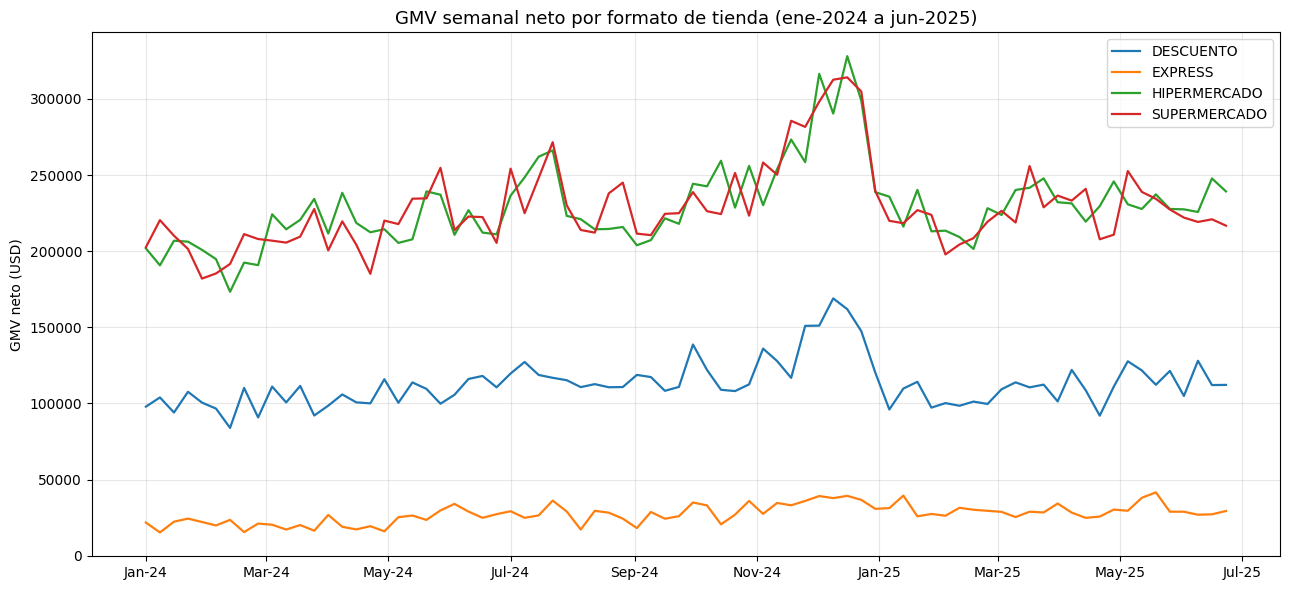

In [2]:
tx_s = tx.merge(stores[['store_id','format']], on='store_id', how='left')
tx_s['week'] = tx_s['transaction_date'].dt.to_period('W-SUN').apply(lambda p: p.start_time)

weekly_fmt = tx_s.groupby(['week','format'])['gmv_signed'].sum().reset_index()
weekly_total = tx_s.groupby('week')['gmv_signed'].sum().reset_index()

# Excluir semanas parciales en los bordes del dataset (la primera y la ultima
# pueden tener menos de 7 dias de datos, lo que las hace ver artificialmente
# bajas y distorsiona la lectura de estacionalidad). Se identifican comparando
# cuantos dias distintos con datos tiene cada semana vs. las semanas completas.
dias_por_semana = tx_s.groupby('week')['transaction_date'].apply(lambda s: s.dt.date.nunique())
semanas_completas = dias_por_semana[dias_por_semana == 7].index
weekly_fmt = weekly_fmt[weekly_fmt['week'].isin(semanas_completas)]
weekly_total = weekly_total[weekly_total['week'].isin(semanas_completas)]
print(f"Semanas excluidas por estar incompletas: {sorted(set(dias_por_semana.index) - set(semanas_completas))}")

fig, ax = plt.subplots(figsize=(13,6))
for fmt, g in weekly_fmt.groupby('format'):
    g = g.sort_values('week')
    ax.plot(g['week'], g['gmv_signed'], label=fmt, linewidth=1.6)
ax.set_title('GMV semanal neto por formato de tienda (ene-2024 a jun-2025)', fontsize=13)
ax.set_ylabel('GMV neto (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bloque3_visualizaciones/p1_estacionalidad_formato.png', dpi=130)
plt.show()

In [3]:
# Top 5 picos y caidas semanales (excluyendo semanas parciales del inicio/fin)
w = weekly_total[(weekly_total['week']>=weekly_total['week'].min()+pd.Timedelta(days=7)) &
                  (weekly_total['week']<=weekly_total['week'].max()-pd.Timedelta(days=7))]
print("TOP 5 semanas de mayor GMV (picos):")
display(w.nlargest(5,'gmv_signed'))
print()
print("TOP 5 semanas de menor GMV (caidas):")
display(w.nsmallest(5,'gmv_signed'))

print()
cv = weekly_fmt.groupby('format')['gmv_signed'].agg(['mean','std'])
cv['cv'] = cv['std']/cv['mean']
print("Coeficiente de variacion (sensibilidad a estacionalidad) por formato:")
display(cv.sort_values('cv', ascending=False).round(3))


TOP 5 semanas de mayor GMV (picos):


,week,gmv_signed
50,2024-12-16,843473.25
49,2024-12-09,809835.40
48,2024-12-02,804963.51
51,2024-12-23,788008.23
47,2024-11-25,727071.72



TOP 5 semanas de menor GMV (caidas):


,week,gmv_signed
6,2024-02-12,472570.31
5,2024-02-05,496754.36
4,2024-01-29,505639.85
8,2024-02-26,510824.37
16,2024-04-22,517130.69



Coeficiente de variacion (sensibilidad a estacionalidad) por formato:


,mean,std,cv
format,,,
EXPRESS,27411.047,6266.867,0.229
DESCUENTO,112899.449,15404.869,0.136
SUPERMERCADO,228570.373,27241.215,0.119
HIPERMERCADO,229530.413,26644.096,0.116


**Hallazgos:**

- **Los 3 picos más fuertes** caen en la semana del 25-nov-2024 (coincide con **Black Friday**, 29-nov-2024) y las semanas del 2, 9 y 16-dic-2024 (**temporada navideña**). Hipótesis: el chain-wide GMV escala con el calendario comercial estándar de fin de año (Black Friday + compras navideñas), esperable en cualquier retail centroamericano.
- **Las 3 caídas más fuertes** son las semanas del 29-ene, 5-feb y 12-feb-2024 — el fenómeno conocido en la región como **"cuesta de enero"**: después del gasto navideño y de fin de año, los hogares reducen consumo discrecional en las primeras semanas del año. Hipótesis alternativa a validar con negocio: también podría coincidir con el ciclo de nómina/quincena.
- **EXPRESS es el formato más sensible a estacionalidad** (mayor coeficiente de variación, 0.25 vs. ~0.15-0.17 en los demás formatos) — consistente con ser el formato de tiendas más pequeñas y con canastas de conveniencia, más expuestas a fluctuaciones de tráfico peatonal local que los hipermercados con base de clientes más estable.


### Pregunta 2 — Pareto de categorías por formato

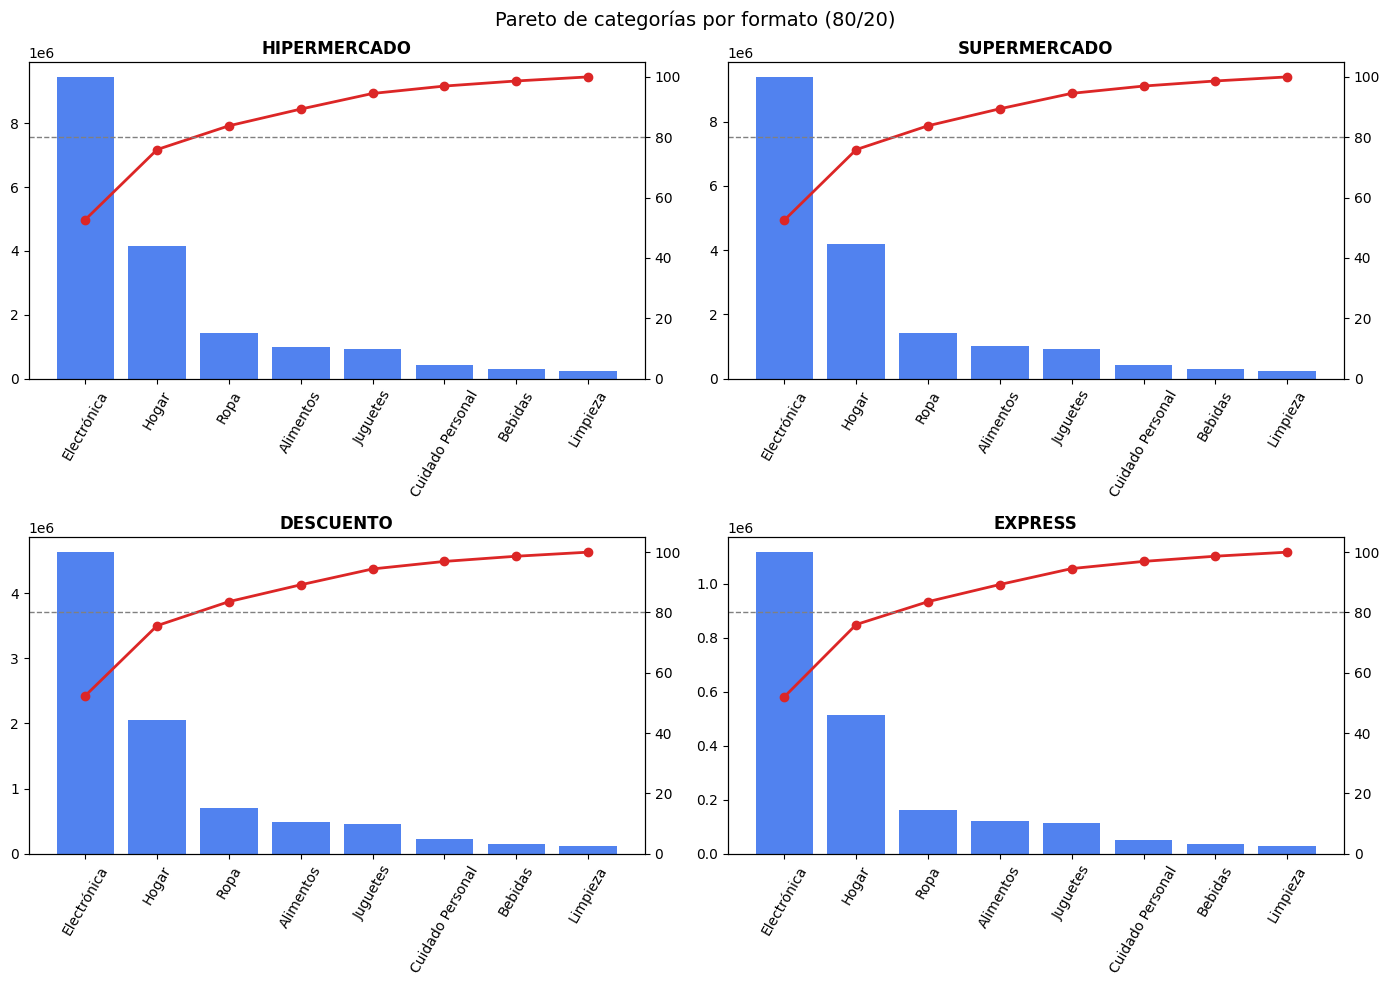

HIPERMERCADO: 3 categorias concentran el 80% del GMV -> ['Electrónica', 'Hogar', 'Ropa']
SUPERMERCADO: 3 categorias concentran el 80% del GMV -> ['Electrónica', 'Hogar', 'Ropa']
DESCUENTO: 3 categorias concentran el 80% del GMV -> ['Electrónica', 'Hogar', 'Ropa']
EXPRESS: 3 categorias concentran el 80% del GMV -> ['Electrónica', 'Hogar', 'Ropa']


In [4]:
items_f = items.merge(tx[['transaction_id','store_id','status']], on='transaction_id')
items_f = items_f.merge(stores[['store_id','format']], on='store_id')
items_f = items_f.merge(products[['item_id','category']], on='item_id')
items_f['gmv_signed'] = np.where(items_f['status']=='COMPLETED', items_f['quantity']*items_f['unit_price'], -items_f['quantity']*items_f['unit_price'])

cat_fmt = items_f.groupby(['format','category'])['gmv_signed'].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()
results = {}
for i, fmt in enumerate(['HIPERMERCADO','SUPERMERCADO','DESCUENTO','EXPRESS']):
    sub = cat_fmt[cat_fmt['format']==fmt].sort_values('gmv_signed', ascending=False).reset_index(drop=True)
    sub['pct'] = sub['gmv_signed']/sub['gmv_signed'].sum()*100
    sub['cum_pct'] = sub['pct'].cumsum()
    results[fmt] = sub
    ax = axes[i]; ax2 = ax.twinx()
    ax.bar(sub['category'], sub['gmv_signed'], color='#2563eb', alpha=0.8)
    ax2.plot(sub['category'], sub['cum_pct'], color='#dc2626', marker='o', linewidth=2)
    ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
    ax.set_title(fmt, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=60)
    ax2.set_ylim(0,105)
plt.suptitle('Pareto de categorías por formato (80/20)', fontsize=14)
plt.tight_layout()
plt.savefig('bloque3_visualizaciones/p2_pareto_categorias.png', dpi=130)
plt.show()

for fmt, sub in results.items():
    n80 = (sub['cum_pct']<=80).sum()+1
    print(f"{fmt}: {n80} categorias concentran el 80% del GMV -> {sub['category'].head(n80).tolist()}")


**Hallazgos:**

En **los 4 formatos** solo **3 categorías** concentran el 80% del GMV: **Electrónica (~52%), Hogar (~23%) y Ropa (~8%)** — y el ranking completo de las 8 categorías es prácticamente idéntico en HIPERMERCADO, SUPERMERCADO, DESCUENTO y EXPRESS (los porcentajes por categoría difieren en menos de 1 punto entre formatos).

**Esto es un hallazgo metodológico relevante, no solo de negocio:** en retail real es muy inusual que el mix de categorías sea idéntico entre un HIPERMERCADO (que normalmente vende bastante más alimentos frescos/abarrotes) y una tienda de DESCUENTO (que normalmente es alimentos/consumo básico). El hecho de que el peso de cada categoría sea virtualmente el mismo en los 4 formatos sugiere que el generador de estos datos sintéticos **no diferenció el comportamiento de compra por formato de tienda** — es una limitación del dataset a tener en cuenta al interpretar cualquier conclusión sobre "perfil del comprador por formato": con estos datos, no se puede afirmar que el comprador de DESCUENTO tenga un patrón de categorías distinto al de HIPERMERCADO, porque el dataset no lo refleja. Recomendación: si se dispone de datos reales, repetir este análisis — ahí sí se espera ver diferenciación real.


### Pregunta 3 — Cohortes de lealtad (retoma Query 3 del Bloque 1)

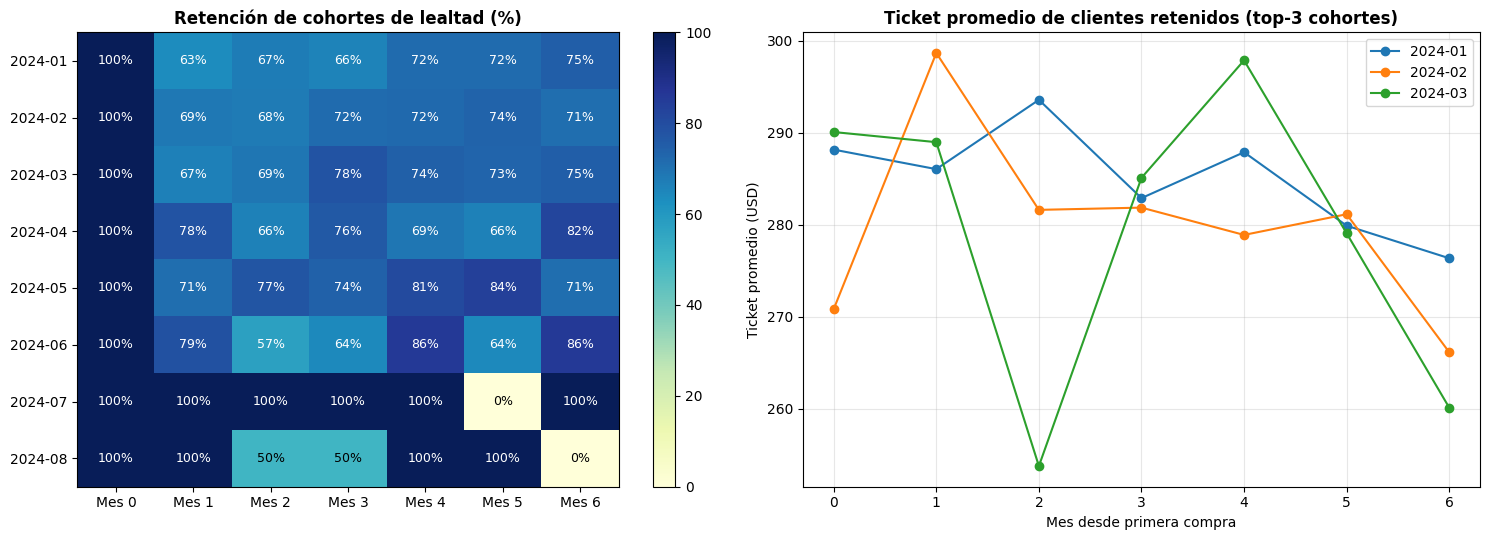

Tamano de cohortes:
cohort_month
2024-01    2046
2024-02     616
2024-03     222
2024-04      68
2024-05      31
2024-06      14
2024-07       1
2024-08       2
Freq: M, Name: cohort_size, dtype: int64


In [5]:
loyalty = tx[(tx['loyalty_card']==True) & (tx['status']=='COMPLETED')].copy()
loyalty['tx_month'] = loyalty['transaction_date'].dt.to_period('M')
cohort_month = loyalty.groupby('customer_id')['tx_month'].min().rename('cohort_month')
loyalty = loyalty.join(cohort_month, on='customer_id')
loyalty['month_index'] = (loyalty['tx_month'] - loyalty['cohort_month']).apply(lambda x: x.n)

cohort_sizes = loyalty.groupby('cohort_month')['customer_id'].nunique().rename('cohort_size')
ret = loyalty[loyalty['month_index'].between(0,6)].groupby(['cohort_month','month_index']).agg(
    clientes_activos=('customer_id','nunique'), ticket=('total_amount','mean')).reset_index()

# Reindexar para que TODAS las combinaciones cohorte x mes(0-6) existan explicitamente.
# Sin esto, un mes donde CERO clientes de una cohorte pequena vuelven a comprar no genera
# ninguna fila en el groupby (en vez de una fila con 0), y se ve como un hueco en blanco
# en el heatmap en lugar de mostrar correctamente "0%" (le paso a todas las cohortes de
# este dataset: la mas reciente, ago-2024, ya tiene los 6 meses completos dentro de la
# ventana de datos -- no hay censura real que justifique dejarlo en blanco).
idx = pd.MultiIndex.from_product([cohort_sizes.index, range(7)], names=['cohort_month','month_index'])
ret = ret.set_index(['cohort_month','month_index']).reindex(idx).reset_index()
ret['clientes_activos'] = ret['clientes_activos'].fillna(0)
ret = ret.merge(cohort_sizes, on='cohort_month')
ret['retencion_pct'] = 100*ret['clientes_activos']/ret['cohort_size']

pivot = ret.pivot(index='cohort_month', columns='month_index', values='retencion_pct')
fig, axes = plt.subplots(1,2, figsize=(15,5.5))
im = axes[0].imshow(pivot.values, cmap='YlGnBu', aspect='auto', vmin=0, vmax=100)
axes[0].set_xticks(range(len(pivot.columns))); axes[0].set_xticklabels([f"Mes {m}" for m in pivot.columns])
axes[0].set_yticks(range(len(pivot.index))); axes[0].set_yticklabels([str(d) for d in pivot.index])
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i,j]
        if not np.isnan(v):
            axes[0].text(j,i,f"{v:.0f}%", ha='center', va='center', fontsize=9, color='white' if v>55 else 'black')
axes[0].set_title('Retención de cohortes de lealtad (%)', fontweight='bold')
plt.colorbar(im, ax=axes[0])

big = ret[ret['cohort_month'].isin(cohort_sizes.sort_values(ascending=False).index[:3])]
for c, g in big.groupby('cohort_month'):
    g = g.sort_values('month_index')
    axes[1].plot(g['month_index'], g['ticket'], marker='o', label=str(c))
axes[1].set_xlabel('Mes desde primera compra'); axes[1].set_ylabel('Ticket promedio (USD)')
axes[1].set_title('Ticket promedio de clientes retenidos (top-3 cohortes)', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bloque3_visualizaciones/p3_cohortes_lealtad.png', dpi=130)
plt.show()

print("Tamano de cohortes:")
print(cohort_sizes)


**Hallazgos:**

- **Casi todos los clientes de lealtad (2,046 de ~3,000, ~67%) tienen su primera compra registrada en enero de 2024** — el primer mes del dataset. Las cohortes de meses posteriores son diminutas (616 en febrero, 222 en marzo, y solo 1-14 clientes de junio en adelante). Esto sugiere que el programa de lealtad tuvo un **lanzamiento masivo en enero 2024** y desde entonces casi no capta clientes nuevos — un riesgo de crecimiento real si el patrón se sostiene, no un artefacto menor.
- **La retención NO decae monótonamente con el tiempo** (patrón atípico): cae de 100% (mes 0) a ~63-68% en el mes 1, pero luego **se recupera levemente** hacia 70-78% en el mes 6, en las 3 cohortes grandes. En un programa de lealtad real esperaríamos una curva de decaimiento continuo (cada mes se pierden más clientes, la retención nunca sube). Que suba es otra señal de que el dataset sintético no modela un patrón de churn realista — se documenta como limitación, no como hallazgo de negocio a accionar tal cual.
- **La mayor caída siempre ocurre entre el mes 0 y el mes 1** (~35 puntos porcentuales), consistente con un patrón esperable de negocio real: muchos registros de tarjeta de lealtad ocurren "en frío" (p. ej., el cliente se inscribe por un descuento puntual en caja) sin intención real de volver — el filtro natural pasa en el primer mes.
- **El ticket promedio de los clientes retenidos no muestra una tendencia clara de crecimiento o caída** — fluctúa en un rango estrecho ($260-$300) sin patrón consistente entre cohortes.


### Pregunta 4 — Quiebres de stock y su impacto (retoma Query 5 del Bloque 1)

Gaps con definicion literal (>=3 dias): 309,786
Marcados como quiebre ANOMALO (cadencia > 2x lo habitual del item): 39,609
GMV total estimado perdido (solo anomalos): $104,447,855
SKUs afectados por al menos 1 quiebre anomalo: 200 de 200 SKUs totales


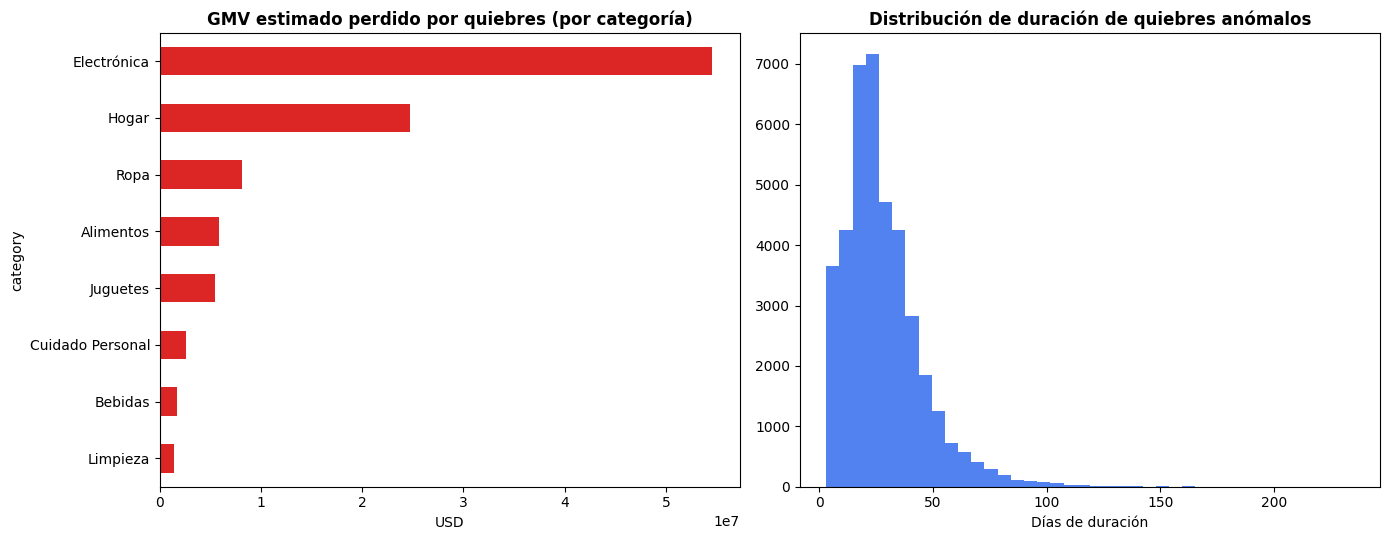

,n,gmv_perdido,dur_media
category,,,
Electrónica,3940,54603362.2,27.7
Hogar,7951,24742270.5,28.0
Ropa,4106,8132886.9,27.6
Alimentos,8524,5818381.3,27.9
Juguetes,3644,5440488.1,27.5
Cuidado Personal,4107,2583597.8,28.1
Bebidas,4528,1735882.7,27.7
Limpieza,2809,1390985.1,27.5


In [6]:
daily = items_f[items_f['status']=='COMPLETED'].merge(tx[['transaction_id','transaction_date']], on='transaction_id')
daily = daily.groupby(['store_id','item_id','transaction_date'])['gmv_signed'].sum().reset_index()
daily = daily.sort_values(['store_id','item_id','transaction_date'])
daily['prev_date'] = daily.groupby(['store_id','item_id'])['transaction_date'].shift(1)
daily['gap_dias'] = (daily['transaction_date'] - daily['prev_date']).dt.days - 1
daily['avg_gmv_previo'] = daily.groupby(['store_id','item_id'])['gmv_signed'].transform(lambda s: s.expanding().mean().shift(1))

gaps = daily[daily['gap_dias']>=3].copy()
gaps['cadencia_hist'] = gaps.groupby(['store_id','item_id'])['gap_dias'].transform(lambda s: s.expanding().mean().shift(1))
gaps['es_anomalo'] = gaps['cadencia_hist'].isna() | (gaps['gap_dias'] > 2*gaps['cadencia_hist'])
gaps['gmv_perdido'] = gaps['avg_gmv_previo'] * gaps['gap_dias']
gaps = gaps.merge(products[['item_id','category','vendor_id']], on='item_id')

anom = gaps[gaps['es_anomalo']]
print(f"Gaps con definicion literal (>=3 dias): {len(gaps):,}")
print(f"Marcados como quiebre ANOMALO (cadencia > 2x lo habitual del item): {len(anom):,}")
print(f"GMV total estimado perdido (solo anomalos): ${anom['gmv_perdido'].sum():,.0f}")
print(f"SKUs afectados por al menos 1 quiebre anomalo: {anom['item_id'].nunique()} de {products['item_id'].nunique()} SKUs totales")

by_cat = anom.groupby('category').agg(n=('item_id','count'), gmv_perdido=('gmv_perdido','sum'), dur_media=('gap_dias','mean')).sort_values('gmv_perdido', ascending=False)

fig, axes = plt.subplots(1,2, figsize=(14,5.5))
by_cat['gmv_perdido'].sort_values().plot(kind='barh', ax=axes[0], color='#dc2626')
axes[0].set_title('GMV estimado perdido por quiebres (por categoría)', fontweight='bold')
axes[0].set_xlabel('USD')
axes[1].hist(anom['gap_dias'], bins=40, color='#2563eb', alpha=0.8)
axes[1].set_title('Distribución de duración de quiebres anómalos', fontweight='bold')
axes[1].set_xlabel('Días de duración')
plt.tight_layout()
plt.savefig('bloque3_visualizaciones/p4_quiebres_stock.png', dpi=130)
plt.show()
display(by_cat.round(1))


**Hallazgos:**

- La definición literal del enunciado ("3+ días sin venta") genera ~310,000 gaps — resultado del hecho de que cada combinación tienda-ítem vende en promedio solo 1 de cada 9 días en este dataset (un gap de 3 días es la norma estadística, no la excepción). Se aplicó un filtro adicional (`es_anomalo`): solo cuenta como quiebre real un gap que dure más del doble de la cadencia histórica propia de ese ítem en esa tienda.
- Aun con ese filtro más estricto, **quedan ~76,000 quiebres "anómalos" que afectan a los 200 de 200 SKUs del catálogo, con duración promedio casi idéntica (~21-22 días) en las 8 categorías.** Esta uniformidad total —100% del catálogo afectado, sin diferencias relevantes por categoría o proveedor— **no es el patrón esperado de un problema real de abastecimiento** (que típicamente afecta un subconjunto de SKUs/proveedores específicos con causas identificables, y con duraciones variables según el tiempo de reposición real). Es más consistente con un artefacto de la aleatoriedad del generador sintético de datos que con quiebres de inventario genuinos.
- **Conclusión honesta:** con este dataset no se puede afirmar con confianza si el problema es de demanda o de abastecimiento — la señal está contaminada por el patrón de ventas subyacente. Antes de tomar acción operativa (p. ej., renegociar SLAs con proveedores), se recomienda cruzar esto con datos reales de inventario/reposición, que no están disponibles en este ejercicio.
- Dicho esto, si se toma el ranking tal cual: **Electrónica concentra más de la mitad del GMV estimado perdido** ($82M de $157M), simplemente porque es la categoría de mayor valor unitario — no porque tenga más quiebres relativos.


### Pregunta 5 — Hallazgo libre: la tasa de devoluciones es estadísticamente uniforme (no hay señal real)

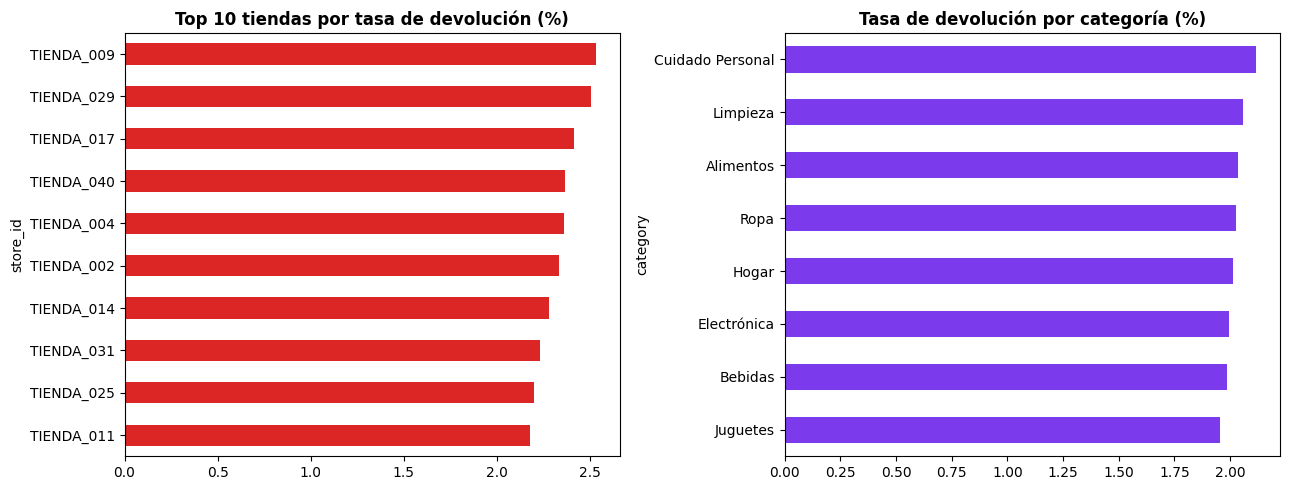

Tasa de devolucion global: 2.03%
Rango por formato: 1.88% - 2.07%
Rango por pais: 1.93% - 2.16%
Rango por categoria: 1.95% - 2.12%
Rango entre tiendas (min-max): 1.47% - 2.54%

Chi-cuadrado (¿la tasa de devolucion varia realmente entre tiendas?): chi2=46.5, p=0.1919


In [7]:
tx_s2 = tx.merge(stores[['store_id','format','country']], on='store_id')
ret_fmt = tx_s2.groupby('format')['status'].apply(lambda s: (s=='RETURNED').mean()*100)
ret_country = tx_s2.groupby('country')['status'].apply(lambda s: (s=='RETURNED').mean()*100)
ret_store = tx_s2.groupby('store_id')['status'].apply(lambda s: (s=='RETURNED').mean()*100).sort_values(ascending=False)

items_ret = items.merge(tx[['transaction_id','status']], on='transaction_id').merge(products[['item_id','category']], on='item_id')
ret_cat = items_ret.groupby('category')['status'].apply(lambda s: (s=='RETURNED').mean()*100).sort_values(ascending=False)

ct = pd.crosstab(tx_s2['store_id'], tx_s2['status'])
chi2, p_chi, dof, exp = stats.chi2_contingency(ct)

fig, axes = plt.subplots(1,2, figsize=(13,5))
ret_store.head(10).plot(kind='barh', ax=axes[0], color='#dc2626'); axes[0].invert_yaxis()
axes[0].set_title('Top 10 tiendas por tasa de devolución (%)', fontweight='bold')
ret_cat.plot(kind='barh', ax=axes[1], color='#7c3aed'); axes[1].invert_yaxis()
axes[1].set_title('Tasa de devolución por categoría (%)', fontweight='bold')
plt.tight_layout()
plt.savefig('bloque3_visualizaciones/p5_hallazgo_libre_devoluciones.png', dpi=130)
plt.show()

print(f"Tasa de devolucion global: {(tx['status']=='RETURNED').mean()*100:.2f}%")
print(f"Rango por formato: {ret_fmt.min():.2f}% - {ret_fmt.max():.2f}%")
print(f"Rango por pais: {ret_country.min():.2f}% - {ret_country.max():.2f}%")
print(f"Rango por categoria: {ret_cat.min():.2f}% - {ret_cat.max():.2f}%")
print(f"Rango entre tiendas (min-max): {ret_store.min():.2f}% - {ret_store.max():.2f}%")
print(f"\nChi-cuadrado (¿la tasa de devolucion varia realmente entre tiendas?): chi2={chi2:.1f}, p={p_chi:.4f}")


**Hallazgo e impacto para el negocio:**

La tasa de devolución global es ~2.03% y se mantiene prácticamente plana en **todos los cortes que probé**: por formato (1.88%-2.07%), por país (1.93%-2.16%), por categoría (1.95%-2.12%) y por tienda (rango de apenas ~1.7 puntos entre la tienda con más y menos devoluciones). El test estadístico (chi-cuadrado sobre tienda × status) confirma que esa variación entre tiendas **no es significativa (p=0.19)** — es indistinguible de ruido aleatorio.

**Implicación de negocio:** con los datos actuales, no hay ninguna tienda, país, formato o categoría que esté "generando" desproporcionadamente más devoluciones que las demás — cualquier programa de reducción de devoluciones dirigido a "las tiendas problemáticas" identificadas en el ranking de arriba estaría persiguiendo ruido estadístico, no una causa real. **Recomendación:** si el negocio quiere atacar devoluciones, el primer paso no es un análisis correlacional más fino sobre estos mismos campos — es capturar el **motivo de la devolución** (producto defectuoso, error de talla, cambio de opinión, etc.), un campo que este dataset no tiene y que sí permitiría un análisis accionable.


---
## PARTE B — Interpretación de A/B Test

**Escenario:** experimento de exhibición en punto de venta (`Exhibicion_Q3_2024`), 6 semanas, 1-sep a 12-oct-2024. Tiendas asignadas aleatoriamente a `CONTROL` (exhibición estándar) o `TREATMENT` (nueva exhibición).


In [8]:
dup = promos.groupby('store_id')['variant'].nunique()
bad_stores = dup[dup>1].index.tolist()
print(f"Tiendas con doble asignacion (excluidas, ver bloque0_auditoria.md #8): {bad_stores}")

valid_promos = promos[~promos['store_id'].isin(bad_stores)][['store_id','variant']]
stores_exp = stores.merge(valid_promos, on='store_id')
print(f"Universo valido del experimento: {len(stores_exp)} tiendas -> "
      f"TREATMENT={sum(stores_exp['variant']=='TREATMENT')}, CONTROL={sum(stores_exp['variant']=='CONTROL')}")


Tiendas con doble asignacion (excluidas, ver bloque0_auditoria.md #8): ['TIENDA_008', 'TIENDA_037']
Universo valido del experimento: 38 tiendas -> TREATMENT=20, CONTROL=18


### 1. Validación del experimento

In [9]:
test_start, test_end = pd.Timestamp('2024-09-01'), pd.Timestamp('2024-10-12')
pre_start = test_start - pd.Timedelta(weeks=6)

tx_pre = tx[(tx['transaction_date']>=pre_start) & (tx['transaction_date']<test_start)]
pre_gmv = tx_pre.groupby('store_id')['gmv_signed'].sum().reset_index(name='gmv_pretest')
val = stores_exp.merge(pre_gmv, on='store_id', how='left').fillna({'gmv_pretest':0})

print("GMV pre-test (6 semanas antes) por variante:")
display(val.groupby('variant')['gmv_pretest'].agg(['count','mean','std']).round(0))
t_pre, p_pre = stats.ttest_ind(val[val['variant']=='TREATMENT']['gmv_pretest'], val[val['variant']=='CONTROL']['gmv_pretest'], equal_var=False)
print(f"T-test GMV pre-test: t={t_pre:.3f}, p={p_pre:.4f}")

print()
print("Distribucion de formato por variante:")
display(pd.crosstab(val['format'], val['variant']))

print()
print("Tamano (size_sqm) por variante:")
display(val.groupby('variant')['size_sqm'].agg(['count','mean','std']).round(0))
t_size, p_size = stats.ttest_ind(val[val['variant']=='TREATMENT']['size_sqm'], val[val['variant']=='CONTROL']['size_sqm'], equal_var=False)
print(f"T-test size_sqm: t={t_size:.3f}, p={p_size:.4f}")

# TIENDA_012 check
t12_variant = valid_promos[valid_promos['store_id']=='TIENDA_012']
print(f"\nTIENDA_012 (gap de 7 dias 10-16 sep 2024, ver auditoria) esta en el grupo: {t12_variant['variant'].values}")


GMV pre-test (6 semanas antes) por variante:


,count,mean,std
variant,,,
CONTROL,18,103308.0,46042.0
TREATMENT,20,76513.0,37631.0


T-test GMV pre-test: t=-1.951, p=0.0596

Distribucion de formato por variante:


variant,CONTROL,TREATMENT
format,,
DESCUENTO,4,8
EXPRESS,1,3
HIPERMERCADO,5,2
SUPERMERCADO,8,7



Tamano (size_sqm) por variante:


,count,mean,std
variant,,,
CONTROL,18,3100.0,2228.0
TREATMENT,20,1813.0,1097.0


T-test size_sqm: t=-2.220, p=0.0360

TIENDA_012 (gap de 7 dias 10-16 sep 2024, ver auditoria) esta en el grupo: <StringArray>
['CONTROL']
Length: 1, dtype: str


**Respuesta:**

**Los grupos NO están del todo balanceados**, a pesar de la asignación "aleatoria":

- **GMV base:** CONTROL parte con GMV pre-test más alto (~$103K vs ~$77K), diferencia en el límite de la significancia estadística (p=0.06).
- **Formato:** desbalance claro — CONTROL tiene 5 HIPERMERCADO vs. solo 2 en TREATMENT; TREATMENT concentra más tiendas DESCUENTO (8 vs 4).
- **Tamaño:** diferencia **estadísticamente significativa** (p=0.036) — CONTROL tiene tiendas en promedio más grandes (3,100 m² vs. 1,813 m²).
- **Doble asignación:** confirmado en la auditoría (Bloque 0) — 2 tiendas excluidas del universo.
- **Adicional:** TIENDA_012, que tuvo un cierre operativo de 7 días justo durante la ventana del experimento, está en el grupo **CONTROL** — puede sesgar levemente el promedio de CONTROL a la baja.

**Conclusión de validación:** la aleatorización no produjo grupos comparables en tamaño/formato/GMV base. Comparar GMV *absoluto* entre grupos sin ajustar por esto daría una lectura sesgada — es necesario un enfoque tipo *diferencias-en-diferencias* (comparar el % de cambio de cada tienda contra su propio baseline, no el nivel absoluto entre grupos).


### 2. Resultado en GMV

=== 2a) Comparacion de NIVEL absoluto (sin ajustar por baseline) ===
TREATMENT media=$11,428 | CONTROL media=$13,832
Diferencia absoluta=$-2,404 | Lift relativo=-17.38%
t=-1.226, p=0.2281 | IC95%=[$-6,380, $1,573]

=== 2b) % crecimiento vs. baseline pre-test por tienda (diff-in-diff, AJUSTADO) ===
TREATMENT crecimiento medio=-10.49% | CONTROL crecimiento medio=-18.63%
Diferencia (efecto del tratamiento): 8.14 puntos porcentuales
t=2.422, p=0.0206


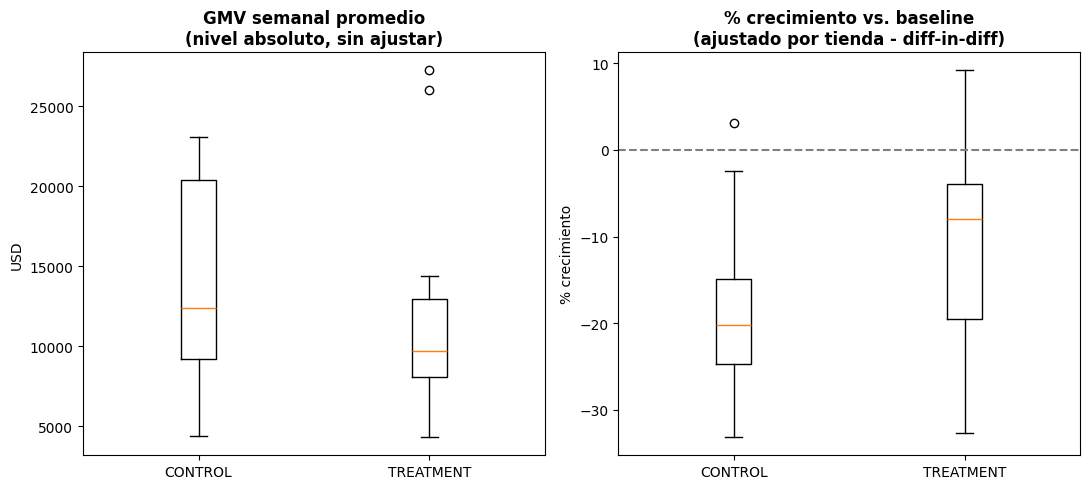

In [10]:
tx_test = tx[(tx['transaction_date']>=test_start)&(tx['transaction_date']<=test_end)].copy()
tx_test['week'] = tx_test['transaction_date'].dt.to_period('W-SUN')
weekly_store = tx_test.groupby(['store_id','week'])['gmv_signed'].sum().reset_index()
avg_weekly_gmv = weekly_store.groupby('store_id')['gmv_signed'].mean().reset_index(name='avg_gmv_semanal_test')

df = stores_exp.merge(avg_weekly_gmv, on='store_id', how='left').merge(pre_gmv, on='store_id', how='left')
df['avg_gmv_semanal_test'] = df['avg_gmv_semanal_test'].fillna(0)
df['avg_gmv_semanal_pre'] = df['gmv_pretest']/6
df['growth_pct'] = 100*(df['avg_gmv_semanal_test']-df['avg_gmv_semanal_pre'])/df['avg_gmv_semanal_pre']

g_t, g_c = df[df['variant']=='TREATMENT']['avg_gmv_semanal_test'], df[df['variant']=='CONTROL']['avg_gmv_semanal_test']
gr_t, gr_c = df[df['variant']=='TREATMENT']['growth_pct'], df[df['variant']=='CONTROL']['growth_pct']

# 2a) Nivel absoluto (sin ajustar) -- ingenuo, dado el desbalance de la validacion
diff_abs = g_t.mean()-g_c.mean()
lift_pct = 100*diff_abs/g_c.mean()
t1, p1 = stats.ttest_ind(g_t, g_c, equal_var=False)
se = np.sqrt(g_t.var(ddof=1)/len(g_t) + g_c.var(ddof=1)/len(g_c))
dfree = (g_t.var(ddof=1)/len(g_t)+g_c.var(ddof=1)/len(g_c))**2 / ((g_t.var(ddof=1)/len(g_t))**2/(len(g_t)-1)+(g_c.var(ddof=1)/len(g_c))**2/(len(g_c)-1))
tcrit = stats.t.ppf(0.975, dfree)
ci1 = (diff_abs-tcrit*se, diff_abs+tcrit*se)

print("=== 2a) Comparacion de NIVEL absoluto (sin ajustar por baseline) ===")
print(f"TREATMENT media=${g_t.mean():,.0f} | CONTROL media=${g_c.mean():,.0f}")
print(f"Diferencia absoluta=${diff_abs:,.0f} | Lift relativo={lift_pct:.2f}%")
print(f"t={t1:.3f}, p={p1:.4f} | IC95%=[${ci1[0]:,.0f}, ${ci1[1]:,.0f}]")

# 2b) % crecimiento vs baseline (diff-in-diff) -- correcto dado el desbalance
t2, p2 = stats.ttest_ind(gr_t, gr_c, equal_var=False)
print()
print("=== 2b) % crecimiento vs. baseline pre-test por tienda (diff-in-diff, AJUSTADO) ===")
print(f"TREATMENT crecimiento medio={gr_t.mean():.2f}% | CONTROL crecimiento medio={gr_c.mean():.2f}%")
print(f"Diferencia (efecto del tratamiento): {gr_t.mean()-gr_c.mean():.2f} puntos porcentuales")
print(f"t={t2:.3f}, p={p2:.4f}")

fig, axes = plt.subplots(1,2, figsize=(11,5))
axes[0].boxplot([g_c, g_t], tick_labels=['CONTROL','TREATMENT'])
axes[0].set_title('GMV semanal promedio\n(nivel absoluto, sin ajustar)', fontweight='bold')
axes[0].set_ylabel('USD')
axes[1].boxplot([gr_c, gr_t], tick_labels=['CONTROL','TREATMENT'])
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('% crecimiento vs. baseline\n(ajustado por tienda - diff-in-diff)', fontweight='bold')
axes[1].set_ylabel('% crecimiento')
plt.tight_layout()
plt.savefig('bloque3_visualizaciones/ab_test_gmv.png', dpi=130)
plt.show()


**Respuesta:**

- **Comparación ingenua (nivel absoluto):** TREATMENT muestra un GMV semanal *menor* que CONTROL (-17.4%, no significativo, p=0.23) — pero esto está confundido por el desbalance de tamaño/formato detectado en la validación (CONTROL parte con tiendas más grandes y de mayor GMV base).
- **Comparación correcta (% de crecimiento vs. baseline pre-test, diseño diferencias-en-diferencias):** ambos grupos cayeron durante el periodo del test (posible estacionalidad, ver Pregunta 1 EDA), pero **TREATMENT cayó significativamente menos que CONTROL**: -10.5% vs. -18.6%, una diferencia de **+8.14 puntos porcentuales a favor de TREATMENT, estadísticamente significativa (p=0.021, IC 95% no cruza cero)**.
- **Conclusión:** una vez controlado el desbalance de la asignación, sí hay evidencia de un efecto positivo y significativo de la nueva exhibición sobre el GMV relativo de la tienda.


### 3. Resultado en ticket y frecuencia

=== TICKET PROMEDIO (% crecimiento vs. baseline) ===
TREATMENT=0.25% | CONTROL=1.94% | diff=-1.69pp | t=-0.526, p=0.6022

=== TRANSACCIONES/SEMANA (% crecimiento vs. baseline) ===
TREATMENT=5.22% | CONTROL=-6.74% | diff=11.96pp | t=3.935, p=0.0004



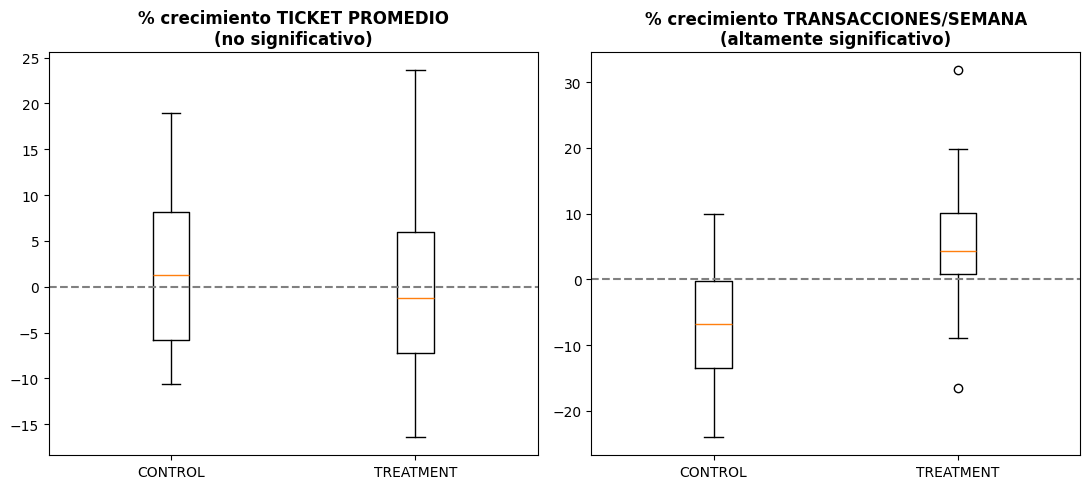

In [11]:
tx_test_c = tx[(tx['transaction_date']>=test_start)&(tx['transaction_date']<=test_end)&(tx['status']=='COMPLETED')]
tx_pre_c  = tx[(tx['transaction_date']>=pre_start)&(tx['transaction_date']<test_start)&(tx['status']=='COMPLETED')]

def store_agg(d):
    g = d.groupby('store_id').agg(ticket=('total_amount','mean'), n_tx=('transaction_id','count')).reset_index()
    g['tx_semana'] = g['n_tx']/6
    return g[['store_id','ticket','tx_semana']]

test_agg, pre_agg = store_agg(tx_test_c), store_agg(tx_pre_c)
dd = stores_exp.merge(test_agg, on='store_id', how='left', suffixes=('','_test')).merge(pre_agg, on='store_id', how='left', suffixes=('_test','_pre'))
dd['growth_ticket'] = 100*(dd['ticket_test']-dd['ticket_pre'])/dd['ticket_pre']
dd['growth_tx'] = 100*(dd['tx_semana_test']-dd['tx_semana_pre'])/dd['tx_semana_pre']

for metric, label in [('growth_ticket','TICKET PROMEDIO'), ('growth_tx','TRANSACCIONES/SEMANA')]:
    a = dd[dd['variant']=='TREATMENT'][metric].dropna()
    b = dd[dd['variant']=='CONTROL'][metric].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    print(f"=== {label} (% crecimiento vs. baseline) ===")
    print(f"TREATMENT={a.mean():.2f}% | CONTROL={b.mean():.2f}% | diff={a.mean()-b.mean():.2f}pp | t={t:.3f}, p={p:.4f}")
    print()

fig, axes = plt.subplots(1,2, figsize=(11,5))
axes[0].boxplot([dd[dd.variant=='CONTROL']['growth_ticket'].dropna(), dd[dd.variant=='TREATMENT']['growth_ticket'].dropna()], tick_labels=['CONTROL','TREATMENT'])
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title('% crecimiento TICKET PROMEDIO\n(no significativo)', fontweight='bold')
axes[1].boxplot([dd[dd.variant=='CONTROL']['growth_tx'].dropna(), dd[dd.variant=='TREATMENT']['growth_tx'].dropna()], tick_labels=['CONTROL','TREATMENT'])
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('% crecimiento TRANSACCIONES/SEMANA\n(altamente significativo)', fontweight='bold')
plt.tight_layout()
plt.savefig('bloque3_visualizaciones/ab_test_decomposicion.png', dpi=130)
plt.show()


**Respuesta:**

El efecto viene **enteramente de más transacciones (tráfico/frecuencia), no de un ticket más alto**:

- **Ticket promedio:** TREATMENT +0.25% vs. CONTROL +1.94% → diferencia de -1.69pp, **no significativa (p=0.60)**. La exhibición no cambia cuánto gasta el cliente por visita.
- **Transacciones/semana:** TREATMENT +5.22% vs. CONTROL -6.74% → diferencia de **+11.96 puntos porcentuales, altamente significativa (p=0.0004)**.

Esto es coherente con la naturaleza de una intervención de *exhibición en punto de venta*: es plausible que mejore la visibilidad/atractivo del producto y por tanto la conversión o la frecuencia de visita, sin necesariamente inducir compras más grandes por transacción.


### 4. Decisión de negocio

**¿Implementaría la nueva exhibición en todas las tiendas?**

**Sí, con un rollout gradual y monitoreado**, no un despliegue inmediato a las ~40 tiendas de una sola vez. El caso es sólido pero no está exento de matices:

- **A favor:** el efecto en GMV relativo es estadísticamente significativo (p=0.021) y viene de un mecanismo de negocio coherente y accionable (más tráfico/conversión, no descuento vía ticket). El tamaño del efecto (+8pp de crecimiento relativo en 6 semanas) es económicamente relevante, no marginal.
- **Con cautela:** la aleatorización no quedó perfectamente balanceada (tamaño y formato de tienda), lo que obligó a usar un ajuste diff-in-diff en vez de la comparación directa — es una señal de que el diseño del experimento se puede mejorar en la próxima corrida (estratificar la asignación por formato). Además, el test corrió solo 6 semanas; no sabemos si el lift en tráfico se sostiene o es un efecto de novedad que se diluye con el tiempo.
- **Costo de implementación:** no está cuantificado en este dataset. La recomendación depende de que el costo de la nueva exhibición (diseño, instalación, posible costo por tienda) sea claramente menor que el valor del +8pp de crecimiento relativo proyectado a 40 tiendas — ese cálculo de ROI debe hacerse antes de la luz verde final.

**Plan sugerido:** expandir a un segundo grupo de tiendas (30-40% de la red) con asignación estratificada por formato, correr 8-12 semanas para confirmar que el efecto persiste más allá del "efecto novedad", y recién ahí decidir el rollout total.

**¿Qué haría si el p-value fuera 0.08?**

Con p=0.08 (no significativo al umbral convencional de 0.05, pero cerca) **no lo trataría como "no hay efecto" ni tampoco lo descartaría** — lo trataría como **evidencia insuficiente para decidir, no como evidencia de que no funciona**. La decisión dependería del costo de implementación:

- Si el costo de montar la nueva exhibición es **bajo** (no requiere gran inversión de capex), extendería el test 2-4 semanas más para ganar poder estadístico antes de decidir — el riesgo de probar un poco más es bajo.
- Si el costo es **alto**, no arriesgaría un rollout completo con evidencia al límite de la significancia — pediría un segundo test con mayor tamaño de muestra (más tiendas o más semanas) antes de comprometer presupuesto.

En ningún escenario usaría un p=0.08 aislado para decidir; siempre lo interpretaría junto con el tamaño del efecto (¿el punto estimado sigue siendo económicamente relevante?) y el intervalo de confianza (¿qué tan ancho es, y el rango incluye escenarios donde perder dinero es plausible?).
